In [2]:
import numpy as np 
import matplotlib.pyplot as plt # %%[jupynvim:cell-sep]
import seaborn as sns
# %%[jupynvim:cell-sep]data = np.load("results_sweep.npz")
import os
os.chdir(os.path.expanduser("~") + "/src/at-gpflow")
result_dir = "experiments/check_approximation_quality/results/"

### Misspecification where the target is undersampled to 10% of the source size, across various proportions of $f_1$.

In [3]:
data = np.load(result_dir + "results_sweep_mixture_checked.npz") # %%[jupynvim:cell-sep]

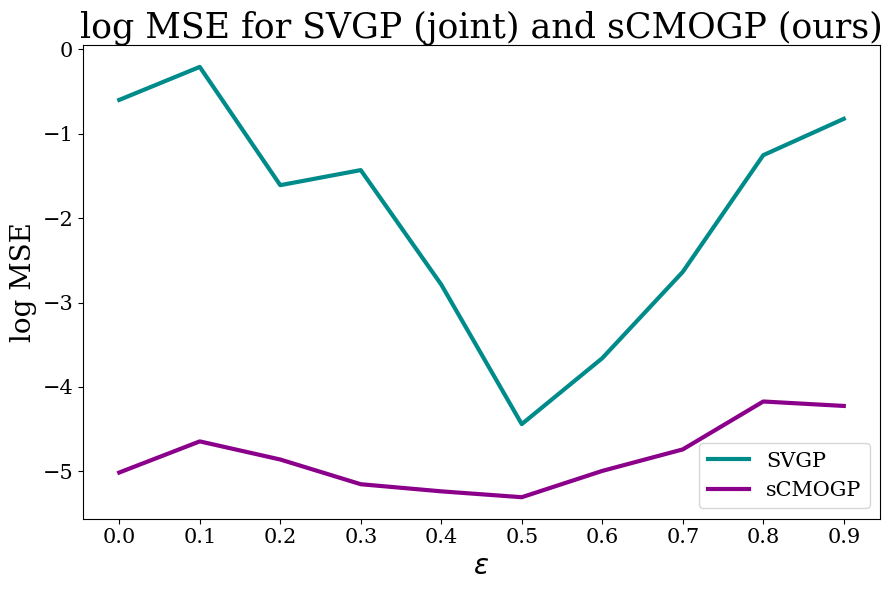

In [4]:
svgp_results = data["svgp"]
cmogp_results = data["cmogp"]
plt.rcParams["font.family"] = "serif"
fig, ax = plt.subplots(1, 1, figsize=(9, 6))
logmean_svgp = np.log(svgp_results.mean(axis=1))
logstd_svgp = np.log(svgp_results.std(axis=1))
logmean_cmogp = np.log(cmogp_results.mean(axis=1))
logstd_cmogp = np.log(cmogp_results.std(axis=1))
ax.plot(logmean_svgp,  linewidth=3, color="darkcyan", label="SVGP")
#ax.fill_between(np.arange(0, 10, 1), logmean_svgp + 2* logstd_svgp, logmean_svgp - 2* logstd_svgp,  linewidth=3, color="darkcyan", alpha=0.25)
#ax.fill_between(np.arange(0, 10, 1), logmean_cmogp + 2* logstd_cmogp, logmean_cmogp - 2* logstd_cmogp,  linewidth=3, color="darkmagenta", alpha=0.25)
ax.plot(logmean_cmogp, linewidth=3, color="darkmagenta", label="sCMOGP")
ax.set_xlabel("$\epsilon$", fontsize=20)
ax.set_xlabel("$\epsilon$", fontsize=20)
ax.set_ylabel("log MSE", fontsize=20)
ax.set_ylabel("log MSE", fontsize=20)
ax.set_xticks( np.arange(0, 10, 1), np.arange(0, 1, 0.1).round(2), fontsize=15)
ax.set_xticks(np.arange(0, 10, 1), np.arange(0, 1, 0.1).round(2), fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_title("log MSE for SVGP (joint) and sCMOGP (ours)", fontsize=25)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

In [5]:
from scipy.stats import ttest_rel, wilcoxon, normaltest
print(normaltest(cmogp_results.mean(axis=1)))
print(normaltest(svgp_results.mean(axis=1)))

print([np.format_float_positional(p) for p in ttest_rel(cmogp_results, svgp_results, axis=1).pvalue.flatten()])

NormaltestResult(statistic=3.0536847632369315, pvalue=0.21722048494675042)
NormaltestResult(statistic=2.8221567103559204, pvalue=0.24388015187986853)
['0.01695984344878821', '0.022970798865046355', '0.004917407641810968', '0.03702296264496935', '0.009108707626322172', '0.0000940782530611609', '0.0053152721683880156', '0.002300888393936122', '0.003641628711929249', '0.06687598103387743']


/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


### Misspecification where the target is not undersampled, across different proportions of $f_1$.

[[0.00989017 0.00889926 0.00971845 0.00892074 0.0099038  0.00847166
  0.00857385 0.00911058 0.00886816 0.00863378 0.01084416 0.00863735
  0.00934039 0.01052078 0.01114621 0.00842823 0.00898596 0.00857089
  0.01175347 0.00830883]
 [0.01196477 0.01133514 0.00807389 0.01048049 0.00918313 0.00869882
  0.00927887 0.01105078 0.00782648 0.00822934 0.01106288 0.0091103
  0.0075643  0.00928566 0.01079498 0.00801771 0.0094163  0.01018531
  0.00981027 0.01030179]
 [0.01218511 0.01131904 0.00677951 0.01026022 0.00681567 0.00937773
  0.00789716 0.00876183 0.01039056 0.00872303 0.00990608 0.00620244
  0.00831977 0.00970654 0.00752394 0.00946036 0.00945976 0.0094826
  0.00979004 0.00980255]
 [0.00997201 0.00939783 0.00947617 0.01052495 0.00923031 0.00897197
  0.01126423 0.00804424 0.01075396 0.00988941 0.01017983 0.00826335
  0.00946758 0.00982932 0.00660823 0.01017752 0.00807914 0.01042221
  0.00901829 0.00863263]
 [0.00797085 0.01153095 0.00956578 0.00993719 0.00927571 0.01169824
  0.00880863 0.008

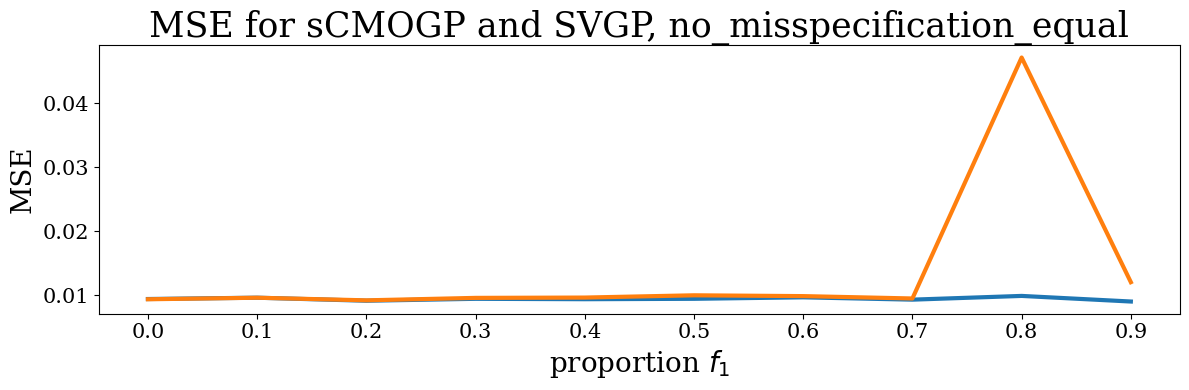

[[0.00667191 0.00961469 0.00821761 0.00747236 0.00919285 0.0074976
  0.00592106 0.00847971 0.00589513 0.01047618 0.00533659 0.00530551
  0.01103995 0.00768351 0.00773412 0.00641895 0.00842676 0.00782412
  0.01239377 0.0089141 ]
 [0.00998157 0.00842741 0.00536345 0.00641951 0.0092633  0.00526966
  0.00586184 0.00978562 0.00524187 0.00727636 0.00425515 0.00625612
  0.00839122 0.00694017 0.00621899 0.00536251 0.00589101 0.00687194
  0.00872168 0.00665974]
 [0.00886715 0.00821706 0.00862798 0.00667427 0.00751318 0.008607
  0.01006085 0.0070968  0.00795635 0.01021108 0.00774961 0.00663292
  0.00830038 0.00835803 0.00796384 0.00872218 0.0051521  0.00931732
  0.00520448 0.00642922]
 [0.00739006 0.01088205 0.00664562 0.00749899 0.01052538 0.00644364
  0.00944284 0.01028656 0.00512644 0.00815673 0.0089015  0.00670015
  0.00315496 0.00625468 0.00970485 0.00799962 0.00867156 0.0073632
  0.01033541 0.01995863]
 [0.00492024 0.00831236 0.0073912  0.00997668 0.0087179  0.00804073
  0.0113855  0.01046

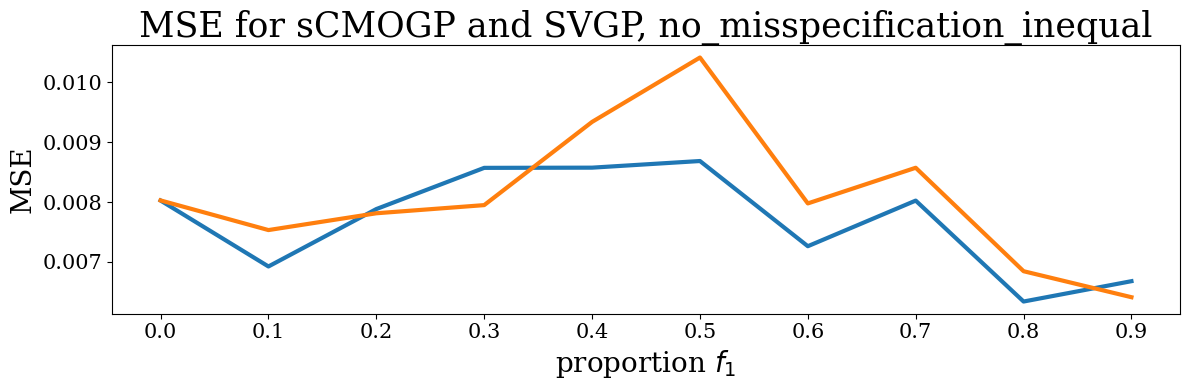

[[0.00667897 0.00965735 0.00822318 0.00747444 0.00919908 0.007504
  0.0059204  0.00848745 0.00589385 0.01050157 0.00526904 0.00530232
  0.01104697 0.00649935 0.00769738 0.00642017 0.0084042  0.00782848
  0.0123323  0.00896083]
 [0.00993949 0.00840506 0.00536895 0.00642046 0.00926713 0.00525304
  0.00584224 0.00979613 0.00523707 0.00729198 0.00426641 0.0062589
  0.00834863 0.00694937 0.00621718 0.00535195 0.00589287 0.00686247
  0.00872117 0.00665832]
 [0.00883909 0.00820404 0.00863081 0.0066764  0.00747506 0.008606
  0.0100598  0.00709657 0.00795589 0.0102074  0.00775589 0.00663445
  0.00829455 0.00840409 0.00798838 0.00871766 0.00516571 0.00932077
  0.00519134 0.00642197]
 [0.00741373 0.01087074 0.00667641 0.00749683 0.01054466 0.00644545
  0.00944257 0.01027569 0.00512662 0.00814352 0.00887604 0.00669663
  0.003156   0.00625069 0.00969229 0.00800693 0.00865398 0.00737091
  0.01033664 0.01993344]
 [0.00492215 0.0083108  0.0073943  0.00998744 0.00871597 0.008039
  0.01138595 0.01045536

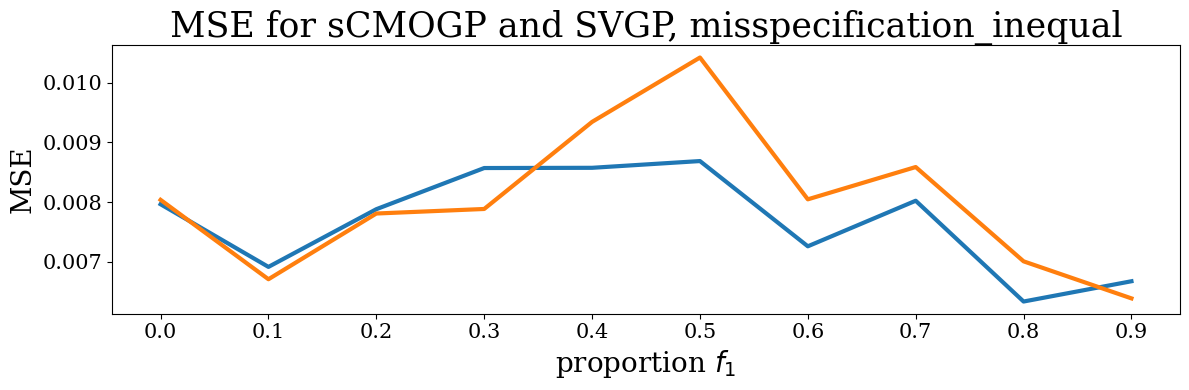

[[0.00988975 0.00890019 0.0097257  0.00891992 0.00990434 0.00847175
  0.00857619 0.00910993 0.00886517 0.00862685 0.01085647 0.00863754
  0.00933572 0.01052155 0.01113763 0.00842647 0.00898701 0.00857124
  0.01174955 0.00830867]
 [0.01197246 0.01133565 0.00807388 0.01048123 0.00918681 0.00869914
  0.0092804  0.01104906 0.00783112 0.00823048 0.01106349 0.00911055
  0.00756721 0.00928608 0.01079487 0.00801553 0.009419   0.01018572
  0.00981145 0.01030095]
 [0.01218396 0.01131782 0.0067787  0.01026112 0.00681297 0.00938029
  0.00789699 0.00877264 0.01039052 0.00872388 0.00990584 0.00620346
  0.00831976 0.00970645 0.00752435 0.00945933 0.00945922 0.00947973
  0.00978814 0.00980387]
 [0.00997202 0.00939757 0.00947595 0.01052463 0.00922952 0.00897247
  0.01126362 0.00804641 0.01075306 0.00988846 0.01017837 0.00826324
  0.00946744 0.00982982 0.0066083  0.01017853 0.00807903 0.01042324
  0.0090191  0.00863451]
 [0.00797054 0.01153018 0.00956647 0.00993761 0.00927507 0.01170057
  0.00880381 0.0

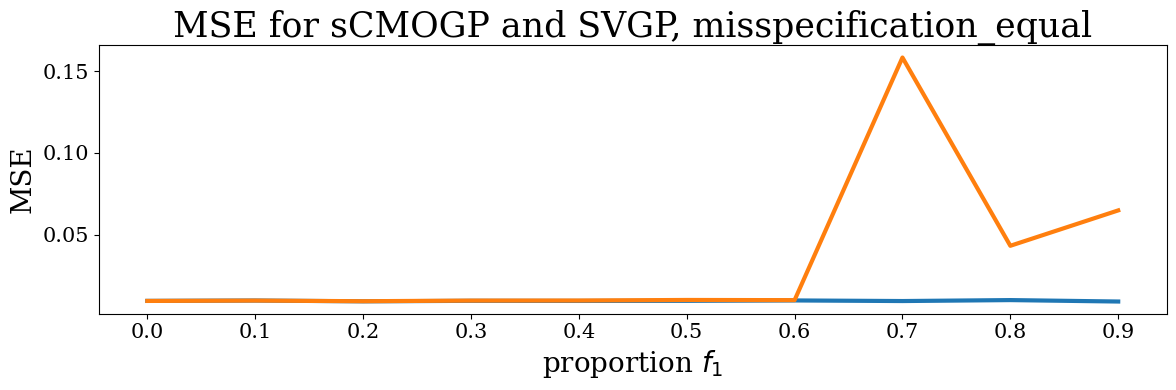

In [12]:
for name in ["no_misspecification_equal", "no_misspecification_inequal", "misspecification_inequal", "misspecification_equal"]:
    data = np.load(result_dir + f"results_matern32_{name}.npz") # %%[jupynvim:cell-sep]
    svgp_results = data["svgp"]
    cmogp_results = data["cmogp"]
    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    ax.plot(svgp_results.mean(axis=1), linewidth=3)
    ax.plot(cmogp_results.mean(axis=1), linewidth=3)
    print(svgp_results, cmogp_results)
    ax.set_xlabel("proportion $f_1$", fontsize=20)
    ax.set_ylabel("MSE", fontsize=20)
    ax.set_xticks(np.arange(0, 10, 1), np.arange(0, 1, 0.1).round(2), fontsize=15)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.set_title(f"MSE for sCMOGP and SVGP, {name}", fontsize=25)
    plt.tight_layout()
    plt.show()

Are the differences statistically meaningful?

In [12]:
from scipy.stats import ttest_rel, wilcoxon, normaltest
print(normaltest(cmogp_results.mean(axis=1)))
print(normaltest(svgp_results.mean(axis=1)))

print([np.format_float_positional(p) for p in wilcoxon(cmogp_results, svgp_results, axis=1).pvalue.flatten()])

NormaltestResult(statistic=28.435769461532267, pvalue=6.687304781149215e-07)
NormaltestResult(statistic=5.670748922218143, pvalue=0.05869654214584045)
['0.26109886169433594', '0.7285060882568359', '0.1893482208251953', '0.24548721313476562', '0.0031528472900390625', '0.0010166168212890625', '0.0001678466796875', '0.0002613067626953125', '0.0010166168212890625', '0.0000820159912109375']


/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


### Sweep over various target size proportions

In [13]:
data = np.load(result_dir + "tbd") # %%[jupynvim:cell-sep]

FileNotFoundError: [Errno 2] No such file or directory: 'experiments/check_approximation_quality/results/tbd'

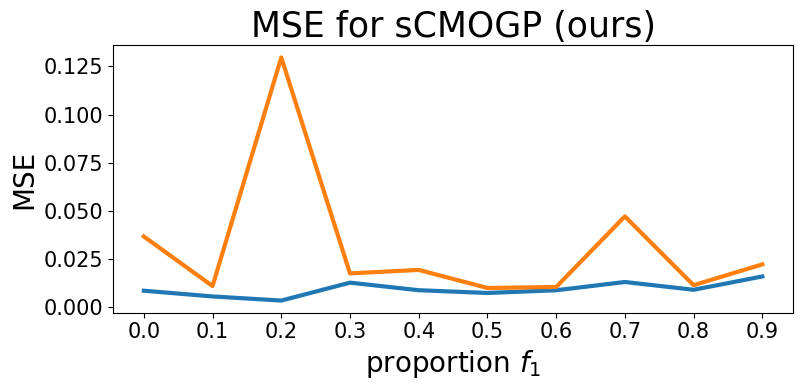

In [ ]:
svgp_results = data["vgp_mse"]
cmogp_results = data["cmogp_mse"]
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(svgp_results.mean(axis=1), linewidth=3)
ax.plot(cmogp_results.mean(axis=1), linewidth=3)
ax.set_xlabel("proportion $f_1$", fontsize=20)
ax.set_xlabel("proportion $f_1$", fontsize=20)
ax.set_ylabel("MSE", fontsize=20)
ax.set_ylabel("MSE", fontsize=20)
ax.set_xticks( np.arange(0, 10, 1), np.arange(0, 1, 0.1).round(2), fontsize=15)
ax.set_xticks(np.arange(0, 10, 1), np.arange(0, 1, 0.1).round(2), fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_title("MSE for SVGP", fontsize=25)
ax.set_title("MSE for sCMOGP (ours)", fontsize=25)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import ttest_rel, wilcoxon, normaltest
print(normaltest(cmogp_results.mean(axis=1)))
print(normaltest(svgp_results.mean(axis=1)))

print([np.format_float_positional(p) for p in wilcoxon(cmogp_results, svgp_results).pvalue.flatten()])

NormaltestResult(statistic=20.58492997857314, pvalue=3.388747810369793e-05)
NormaltestResult(statistic=0.24746688837077607, pvalue=0.8836153423015911)
['0.001953125']
